# 3.C2 Toepassingen op Marketing

In deze notebook maken we gebruik van NumPy en Pandas om klantengegevens te analyseren.

## Maak klantengegevens aan

Hieronder gebruiken we de verschillende `random`-functies in NumPy om klantengegevens te simuleren:

In [1]:
import pandas as pd
import numpy as np

np.random.seed(42)

n_klanten = 100

klant_ids = np.arange(1, n_klanten + 1)
leeftijden = np.random.randint(18, 70, size=n_klanten)
maandelijkse_uitgaven = np.round(np.random.uniform(50, 1000, size=n_klanten), 2)

# Score van 1 tot 10
loyaliteitsscore = np.random.randint(1, 11, size=n_klanten)  

klant_data = pd.DataFrame({
    "Klant_ID": klant_ids,
    "Leeftijd": leeftijden,
    "Maandelijkse_Uitgaven": maandelijkse_uitgaven,
    "Loyaliteitsscore": loyaliteitsscore
})

klant_data.head()

C:\Users\u0092789\AppData\Local\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


,Klant_ID,Leeftijd,Maandelijkse_Uitgaven,Loyaliteitsscore
0,1,56,207.00,3
1,2,69,64.85,4
2,3,46,452.23,4
3,4,32,425.14,3
4,5,60,328.81,10


## Wijs klant een marketingactie toe

Nu gaan we een extra kolom aanmaken in onze DataFrame met de `apply()` functie. Deze wordt op elke rij toegepast en zal dus de verschillende kolommen per rij kunnen aanspreken. Zo zal in de functie `marketing_campagne()` het argument `rij` dienen als een `Series()`-object dat 1 rij weergeeft, waardoor we de kolomnamen kunnen gebruiken om data op te vragen zoals bv. `rij['Loyaliteitsscore']`. Dit doen we om, per rij, de klant een bepaalde categorie/marketing-actie toe te wijzen:

In [2]:
def marketing_campagne(rij):
    if rij['Maandelijkse_Uitgaven'] > 500:
        return 'Exclusieve aanbieding'
    elif rij['Loyaliteitsscore'] > 7:
        return 'Speciale beloning'
    elif rij['Maandelijkse_Uitgaven'] < 200:
        return 'Kortingsbon voor meer uitgaven'
    else:
        return 'Standaardaanbieding'

# pas functie op elke rij toe en stop resultaat in een nieuwe kolom
klant_data['Campagne_Aanbieding'] = klant_data.apply(marketing_campagne, axis=1)

klant_data.head(10)

,Klant_ID,Leeftijd,Maandelijkse_Uitgaven,Loyaliteitsscore,Campagne_Aanbieding
0,1,56,207.00,3,Standaardaanbieding
1,2,69,64.85,4,Kortingsbon voor meer uitgaven
2,3,46,452.23,4,Standaardaanbieding
3,4,32,425.14,3,Standaardaanbieding
4,5,60,328.81,10,Speciale beloning
5,6,25,63.38,3,Kortingsbon voor meer uitgaven
6,7,38,238.90,3,Standaardaanbieding
7,8,56,725.77,4,Exclusieve aanbieding
8,9,36,800.67,7,Exclusieve aanbieding
9,10,40,625.66,4,Exclusieve aanbieding


## Berekenen van de Customer Lifetime Value (CLV)

De CLV is een veelgebruikte methode om te bepalen hoeveel een klant nog zal 'opbrengen' in de toekomst. Die berekenen we volgens de formule $$CLV= o\cdot \frac{r}{1 + (i-r)}$$ waarbij 
- $i$ de intrestvoet om het tijdsaspect van geld in kaart te brengen
- $o$ de uitgaven die klanten maken (mogelijke opbrengst)
- $r$ de retentieratio, i.e., hoe waarschijnlijk het is dat een klant blijft. We maken van die laatste een percentage om ze in de formule te kunnen gebruiken.

Daarna kunnen we weer gewoon `apply()` gebruiken per rij: 

In [ ]:
# stel de intrestvoet in (0.1 (10% per jaar), 0.008 per maand)
intrestvoet = 0.008

def bereken_clv(row):
    loyaliteit = row['Loyaliteitsscore'] / 10
    maandelijkse_uitgaven = row['Maandelijkse_Uitgaven']

    clv = maandelijkse_uitgaven * loyaliteit/(1+(intrestvoet-loyaliteit))
    return clv

klant_data['CLV'] = klant_data.apply(bereken_clv, axis=1)

klant_data.groupby(['Loyaliteitsscore']).mean(numeric_only=True)

,Klant_ID,Leeftijd,Maandelijkse_Uitgaven,CLV
Loyaliteitsscore,,,,
1,60.133333,39.200000,476.318000,52.457930
2,45.428571,52.857143,491.467143,121.650283
3,48.000000,46.823529,449.924118,190.645813
4,39.615385,46.538462,450.863846,296.620951
5,73.750000,49.125000,528.507500,520.184547
6,70.333333,34.555556,435.316667,640.171569
7,35.285714,41.428571,641.545714,1458.058442
8,51.727273,46.454545,474.942727,1826.702797
9,40.800000,32.600000,595.127000,4959.391667


## Filteren van klanten

Pandas maakt filteren makkelijk. We gebruiken hieronder enkele filters om enkel bepaalde interessante klanten te weerhouden. Deze resulteren in 3 dataframes die we daarna samenbrengen door de originele dataset te filteren door te controleren of de rijen in de aparte dataframes zitten via `isin()`. `isin()` zal een reeks van indices teruggeven die worden gebruikt over `klant_data`. We zoeken naar klanten in 1 van de drie dataframe, dus gebruiken we `|` voor een of-operatie:

In [4]:
hoog_clv_klanten = klant_data[klant_data['CLV'] > 20000]

loyaliteit_klanten = klant_data[klant_data['Loyaliteitsscore'] >= 8]

lage_uitgaven_klanten = klant_data[klant_data['Maandelijkse_Uitgaven'] < 200]

filtered_data = klant_data[(klant_data['Klant_ID'].isin(hoog_clv_klanten['Klant_ID'])) | 
                            (klant_data['Klant_ID'].isin(loyaliteit_klanten['Klant_ID'])) | 
                            (klant_data['Klant_ID'].isin(lage_uitgaven_klanten['Klant_ID']))]

filtered_data[['Klant_ID', 'Maandelijkse_Uitgaven', 'Loyaliteitsscore', 'CLV', 'Campagne_Aanbieding']].head(10)

,Klant_ID,Maandelijkse_Uitgaven,Loyaliteitsscore,CLV,Campagne_Aanbieding
1,2,64.85,4,42.664474,Kortingsbon voor meer uitgaven
4,5,328.81,10,41101.250000,Speciale beloning
5,6,63.38,3,26.855932,Kortingsbon voor meer uitgaven
10,11,929.99,9,7749.916667,Exclusieve aanbieding
12,13,919.21,8,3535.423077,Exclusieve aanbieding
15,16,140.64,8,540.923077,Speciale beloning
17,18,685.40,9,5711.666667,Exclusieve aanbieding
18,19,682.63,9,5688.583333,Exclusieve aanbieding
21,22,583.18,10,72897.500000,Exclusieve aanbieding
24,25,856.47,10,107058.750000,Exclusieve aanbieding


## Visualisaties

We gebruiken weer Matplotlib om verschillende plots te maken die ons de resultaten helpen interpreteren:

### Histogram van de CLV

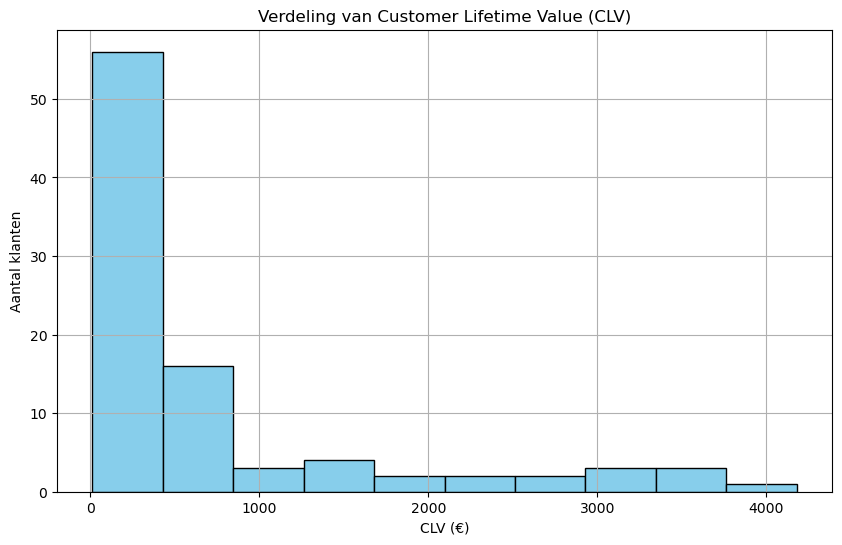

In [5]:
import matplotlib.pyplot as plt

lage_CLV = klant_data[klant_data['CLV']<5000]['CLV']

plt.figure(figsize=(10, 6))
plt.hist(lage_CLV, bins=10, color='skyblue', edgecolor='black')
plt.title('Verdeling van Customer Lifetime Value (CLV)')
plt.xlabel('CLV (€)')
plt.ylabel('Aantal klanten')
plt.grid(True)
plt.show()

### Spreidingsplot van de CLV vs. de maandelijkse uitgaven

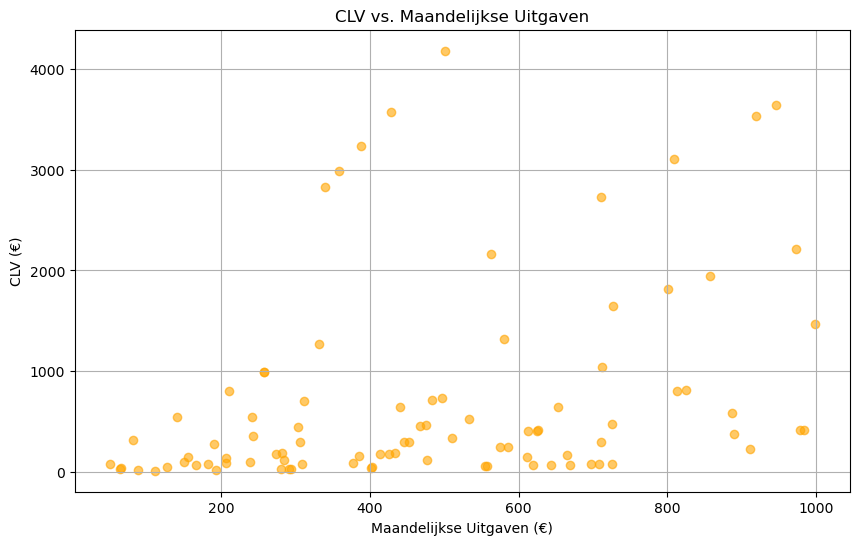

In [6]:
plt.figure(figsize=(10, 6))

lage_CLV = klant_data[klant_data['CLV']<5000]

plt.scatter(lage_CLV['Maandelijkse_Uitgaven'], lage_CLV['CLV'], alpha=0.6, color='orange')
plt.title('CLV vs. Maandelijkse Uitgaven')
plt.xlabel('Maandelijkse Uitgaven (€)')
plt.ylabel('CLV (€)')
plt.grid(True)
plt.show()

### Taartdiagram voor klantensegmenten

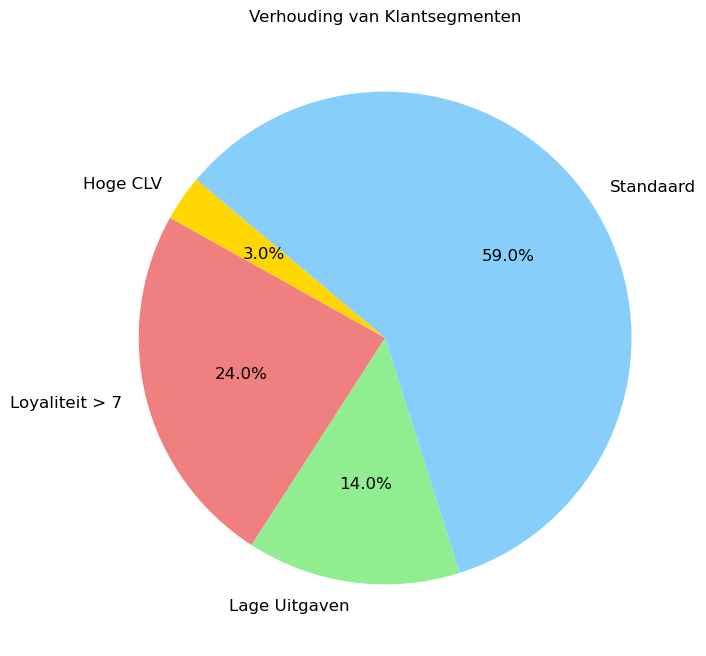

In [7]:
# Tel het aantal klanten in elk segment
hoog_clv_count = len(hoog_clv_klanten)
loyaliteit_count = len(loyaliteit_klanten)
lage_uitgaven_count = len(lage_uitgaven_klanten)
standaard_count = len(klant_data) - hoog_clv_count - loyaliteit_count - lage_uitgaven_count

# Labels en waarden voor de taartdiagram
labels = ['Hoge CLV', 'Loyaliteit > 7', 'Lage Uitgaven', 'Standaard']
sizes = [hoog_clv_count, loyaliteit_count, lage_uitgaven_count, standaard_count]
colors = ['gold', 'lightcoral', 'lightgreen', 'lightskyblue']

# Plotten van de taartdiagram
plt.figure(figsize=(8, 8))
plt.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=140, textprops={'fontsize': 12})
plt.title('Verhouding van Klantsegmenten')
plt.show()